# BioSemi 64-Channel ERP Preprocessing Pipeline

This notebook implements a complete MNE-Python preprocessing pipeline for
BioSemi ActiveTwo 64-channel EEG recordings with external EOG and ECG channels.
It is designed for feedback-locked ERP analysis in a reversal-learning bandit task.

**Scope:** Preprocessing and quality control only — no inferential analysis.

### Processing steps

0. Setup and configuration
1. Load raw BDF data
2. Set montage (biosemi64)
3. Set external channel types, create bipolar EOG/ECG derivations, drop unused channels
4. Raw QC: visual inspection and PSD
5. Notch filter (50 / 100 Hz)
6. Detect and mark bad channels
7. Two-stream bandpass filtering (ERP: 0.1–40 Hz; ICA: 1–40 Hz)
8. Optional resample to 256 Hz
9. Fit ICA on the 1 Hz-filtered stream (optionally excluding mastoids)
10. Detect EOG / ECG artifact components via bipolar channels; visual review
11. Apply ICA to the ERP stream
12. Interpolate bad channels; set reference (average or linked mastoids)
13. Extract events from the BioSemi Status channel
14. Define event-ID mapping and select feedback events
15. Attach behavioural metadata from CSV / TSV
16. Create feedback-locked epochs (−0.2 – 0.8 s)
17. Reject bad epochs (150 µV peak-to-peak)
18. Save cleaned data and QC summary
19. Final QC plots

### How to use

Edit **only the Parameters cell** (cell 0d) to adapt this notebook to a new
subject, session, or experiment. All paths, filter settings, ICA configuration,
and rejection thresholds are defined there. Then run all cells top to bottom.

In [31]:
import json
from pathlib import Path

import mne
import numpy as np
import pandas as pd
from mne.preprocessing import ICA
mne.set_log_level("WARNING")
%matplotlib inline

## Parameters

All tunable pipeline settings are collected in the next cell. Edit these
values to match your subject, recording setup, and analysis choices.
Nothing else in the notebook needs to be modified for a standard run.

In [32]:
# ===========================================================================
# PARAMETERS — edit this cell for each subject / experiment
# ===========================================================================

# ---- Subject / Session ----
SUBJECT = "01"
SESSION = "01"
TASK    = "Cannonball MF"

# ---- Paths (relative to this notebook's location) ----
PROJECT_ROOT    = Path("..").resolve()
SOURCEDATA_DIR  = PROJECT_ROOT / "data" / "sourcedata"
DERIVATIVES_DIR = PROJECT_ROOT / "data" / "derivatives" / "mne_preproc"

# ---- Input file ----
# Name of the BDF/BDF+ file inside SOURCEDATA_DIR (with or without extension).
# Set to None to auto-discover the first .bdf file in SOURCEDATA_DIR.
BDF_FILENAME = "P001_S1_Cannonball_MF"

# ---- Channel configuration ----
# BioSemi external channels (EXG1–EXG8) mapped to MNE channel types.
# Wiring: EXG1/2 = mastoids (EEG), EXG3/4 = ECG, EXG5/6 = EOG, EXG7/8 = unused.
EXG_MAPPING = {
    "EXG1": "eeg",   # Left mastoid  (kept as EEG for optional linked-mastoid ref)
    "EXG2": "eeg",   # Right mastoid (kept as EEG for optional linked-mastoid ref)
    "EXG3": "ecg",   # ECG+
    "EXG4": "ecg",   # ECG-
    "EXG5": "eog",   # EOG+ (e.g., above or below eye)
    "EXG6": "eog",   # EOG- (e.g., outer canthus)
    "EXG7": "misc",  # unused
    "EXG8": "misc",  # unused
}
DROP_CHANNELS    = ["EXG7", "EXG8"]           # misc externals to drop
MASTOID_CHANNELS = ["EXG1", "EXG2"]           # mastoid electrodes
LINE_FREQ        = 50                         # Hz (mains frequency)
MONTAGE_NAME     = "biosemi64"

# ---- Reference ----
# "average" = average of all EEG channels (default, recommended for ERP)
# "mastoids" = linked mastoids (mean of EXG1 + EXG2; mastoid channels dropped after)
REFERENCE = "average"

# ---- ICA channel selection ----
ICA_EXCLUDE_MASTOIDS = True   # exclude mastoid channels from ICA fitting

# ---- Bipolar derivations ----
# Created from EXG pairs via mne.set_bipolar_reference(); originals are dropped.
BIPOLAR_ECG_ANODE   = "EXG3"
BIPOLAR_ECG_CATHODE = "EXG4"
BIPOLAR_ECG_NAME    = "ECG_bipolar"

BIPOLAR_EOG_ANODE   = "EXG5"
BIPOLAR_EOG_CATHODE = "EXG6"
BIPOLAR_EOG_NAME    = "EOG_bipolar"

# ---- Filtering ----
NOTCH_FREQS = [50, 100]       # power-line harmonics (Hz)
ERP_L_FREQ  = 0.1             # ERP stream high-pass (Hz)
ERP_H_FREQ  = 40.0            # ERP stream low-pass  (Hz)
ICA_L_FREQ  = 1.0             # ICA stream high-pass (Hz)
ICA_H_FREQ  = 40.0            # ICA stream low-pass  (Hz)

# ---- Resampling ----
RESAMPLE_SFREQ = 256          # Hz — set to None to skip resampling

# ---- ICA ----
ICA_N_COMPONENTS = 0.99       # variance-explained threshold
ICA_METHOD       = "fastica"
ICA_RANDOM_STATE = 42
ICA_MAX_ITER     = 1000


# ---- Events ----
# Integer trigger codes in the BDF Status channel -> human-readable names.
# Update if your trigger scheme changes.
EVENT_ID = {
    "system.test": 99,
    "system.initialized": 1,
    "system.error": 2,
    "game.start": 10,
    "game.end": 11,
    "game.response": 12,
    "game.ballFired": 13,
    "game.alienHit": 14,
    "game.ballMissed": 15,
    "game.asteroidHit": 16,
    "game.ballExplode": 17,    # LOSS outcome
    "game.newTrial": 18,
    "game.asteroidTail": 19,   # REWARD outcome
}

# Outcome events used for epoching (one per trial in your current task)
OUTCOME_EVENT_NAMES = ["game.loss", "game.reward"]

# ---- Manual annotation handling ----
# If True, Step 12b will open an interactive browser so you can annotate BAD segments.
# Any annotations whose description starts with "BAD" will be excluded during epoching
# when REJECT_BY_ANNOTATION=True.
RUN_MANUAL_ANNOTATION = False
REJECT_BY_ANNOTATION = True

# ---- Epoching ----
EPOCH_TMIN = -0.2            # seconds before event
EPOCH_TMAX =  0.8            # seconds after event
BASELINE   = (-0.2, 0)       # baseline correction window

# ---- Artifact rejection (epoch-level) ----
# Peak-to-peak threshold: reject epochs with residual large-amplitude artifacts.
REJECT_EEG = 150e-6          # 150 µV (tune per dataset)
# Flat threshold: reject epochs with near-flat EEG (electrode dropout).
REJECT_FLAT_EEG = 1e-6       # 1 µV

In [33]:
# ===========================================================================
# Construct file paths and create output directory
# ===========================================================================
sub_dir = f"sub-{SUBJECT}"
ses_dir = f"ses-{SESSION}"

# --- Resolve BDF path ---
# If BDF_FILENAME is set, look for it (exact match or with .bdf extension).
# If BDF_FILENAME is None, auto-discover the first .bdf file in SOURCEDATA_DIR.
if BDF_FILENAME is not None:
    bdf_path = SOURCEDATA_DIR / BDF_FILENAME
    # If the name was given without an extension and doesn't exist, try .bdf
    if not bdf_path.exists() and not bdf_path.suffix:
        bdf_path_ext = bdf_path.with_suffix(".bdf")
        if bdf_path_ext.exists():
            bdf_path = bdf_path_ext
else:
    # Auto-discover: pick the first .bdf file in SOURCEDATA_DIR
    bdf_candidates = sorted(SOURCEDATA_DIR.glob("*.bdf"))
    assert len(bdf_candidates) > 0, (
        f"No .bdf files found in {SOURCEDATA_DIR} — set BDF_FILENAME manually"
    )
    bdf_path = bdf_candidates[0]
    if len(bdf_candidates) > 1:
        print(f"WARNING: Multiple .bdf files found, using first: {bdf_path.name}")

assert bdf_path.exists(), f"BDF file not found: {bdf_path}"

# MNE requires BDF files to have a .bdf extension — rename if missing
if bdf_path.suffix.lower() != ".bdf":
    bdf_path_renamed = bdf_path.with_suffix(".bdf")
    if not bdf_path_renamed.exists():
        bdf_path.rename(bdf_path_renamed)
        print(f"Renamed: {bdf_path.name} -> {bdf_path_renamed.name}")
    bdf_path = bdf_path_renamed

# Behavioural file — look for a matching .tsv/.csv alongside the BDF
behav_path = None
for ext in (".tsv", ".csv"):
    candidate = bdf_path.with_name(bdf_path.stem + f"_behav{ext}")
    if candidate.exists():
        behav_path = candidate
        break

out_dir = DERIVATIVES_DIR / sub_dir / ses_dir
out_dir.mkdir(parents=True, exist_ok=True)

print(f"Input BDF  : {bdf_path}")
print(f"Behavioural: {behav_path}  (found: {behav_path is not None})")
print(f"Output dir : {out_dir}")

Input BDF  : /Users/arthurhsia/Desktop/Psychology/EEG/data/sourcedata/P001_S1_Cannonball_MF.bdf
Behavioural: /Users/arthurhsia/Desktop/Psychology/EEG/data/sourcedata/P001_S1_Cannonball_MF_behav.csv  (found: True)
Output dir : /Users/arthurhsia/Desktop/Psychology/EEG/data/derivatives/mne_preproc/sub-01/ses-01


In [34]:

out_dir = DERIVATIVES_DIR / sub_dir / ses_dir
out_dir.mkdir(parents=True, exist_ok=True)

print(f"Output dir : {out_dir}")

Output dir : /Users/arthurhsia/Desktop/Psychology/EEG/data/derivatives/mne_preproc/sub-01/ses-01


---
## Step 1 — Load Raw BDF Data

BioSemi ActiveTwo records EEG in the **BDF** (BioSemi Data Format) container,
a 24-bit variant of EDF+. The file contains:

- **64 scalp EEG channels** (named A1–A32 and B1–B32 in the BioSemi convention)
- **8 external channels** (EXG1–EXG8) for EOG, ECG, and reference electrodes
- A **Status channel** that encodes trigger codes in its lower 16 bits

`preload=True` reads all data into memory, which is required for in-place
filtering. For very large files on memory-constrained machines, consider
processing in segments.

In [35]:
raw = mne.io.read_raw_bdf(str(bdf_path), preload=True, verbose=False)
raw.info["line_freq"] = LINE_FREQ

print(raw.info)
print(f"\nChannels : {len(raw.ch_names)}")
print(f"Sfreq    : {raw.info['sfreq']} Hz")
print(f"Duration : {raw.times[-1]:.1f} s")

<Info | 9 non-empty values
 bads: []
 ch_names: Fp1, AF7, AF3, F1, F3, F5, F7, FT7, FC5, FC3, FC1, C1, C3, C5, ...
 chs: 72 EEG, 1 Stimulus
 custom_ref_applied: False
 highpass: 0.0 Hz
 line_freq: 50.0
 lowpass: 417.0 Hz
 meas_date: 2026-02-04 14:38:39 UTC
 nchan: 73
 projs: []
 sfreq: 2048.0 Hz
 subject_info: <subject_info | his_id: >
>

Channels : 73
Sfreq    : 2048.0 Hz
Duration : 1740.0 s


---
## Step 2 — Set Montage (biosemi64)

The **montage** defines the 3-D coordinates of each electrode on the scalp.
BioSemi 64 uses a radially equidistant layout:

- **A1–A32** cover the left hemisphere
- **B1–B32** cover the right hemisphere

MNE ships a built-in `biosemi64` montage.  Setting it enables topographic
plots, spatial interpolation of bad channels, and (if needed) source
localisation.

`on_missing="warn"` avoids errors for the EXG and Status channels that
have no defined scalp position.

/var/folders/bg/35xhpjxn5mn8n4n2k4h8pc8w0000gn/T/ipykernel_45511/2527459852.py:2: RuntimeWarning: DigMontage is only a subset of info. There are 8 channel positions not present in the DigMontage. The channels missing from the montage are:

['EXG1', 'EXG2', 'EXG3', 'EXG4', 'EXG5', 'EXG6', 'EXG7', 'EXG8'].

Consider using inst.rename_channels to match the montage nomenclature, or inst.set_channel_types if these are not EEG channels, or use the on_missing parameter if the channel positions are allowed to be unknown in your analyses.
  raw.set_montage(montage, on_missing="warn")


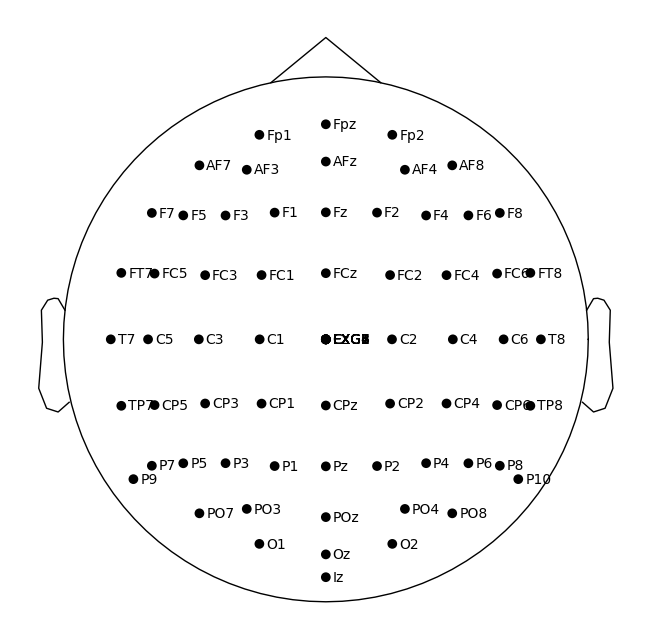

Text(0.5, 1.02, 'biosemi64 montage')

In [36]:
montage = mne.channels.make_standard_montage(MONTAGE_NAME)
raw.set_montage(montage, on_missing="warn")

fig = raw.plot_sensors(show_names=True)
fig.suptitle(f"{MONTAGE_NAME} montage", y=1.02)

---
## Step 3 — Set External Channel Types, Create Bipolar Derivations, Drop Unused

BioSemi's external channels (EXG1–EXG8) are loaded as generic EEG by default.
We remap them to reflect the actual recording montage:

| Channel | Role | MNE type |
|---------|------|----------|
| EXG1 / EXG2 | Left / right mastoid | `eeg` (kept for optional linked-mastoid reference) |
| EXG3 / EXG4 | ECG (+/−) | `ecg` |
| EXG5 / EXG6 | EOG (+/−) | `eog` |
| EXG7 / EXG8 | Unused | `misc` → dropped |

After setting types, we create **bipolar derivations** via
`mne.set_bipolar_reference`:

- **ECG_bipolar** = EXG3 − EXG4 (cardiac signal, type `ecg`)
- **EOG_bipolar** = EXG5 − EXG6 (ocular signal, type `eog`)

Bipolar derivation subtracts the cathode from the anode, producing a single
channel with improved signal-to-noise for artifact detection. The original
EXG pairs are dropped automatically (`drop_refs=True`).

The mastoid channels (EXG1 / EXG2) and the **Status** channel are kept for
later use (reference and event extraction, respectively).

In [37]:
# Set channel types from EXG_MAPPING
# (EXG1/EXG2 are already "eeg" after loading; setting them explicitly is a no-op)
ch_type_map = {ch: typ for ch, typ in EXG_MAPPING.items() if ch in raw.ch_names}
raw.set_channel_types(ch_type_map)
print(f"Set channel types: {ch_type_map}")

# Drop unused external channels
to_drop = [ch for ch in DROP_CHANNELS if ch in raw.ch_names]
if to_drop:
    raw.drop_channels(to_drop)
    print(f"Dropped unused channels: {to_drop}")

# Create bipolar ECG derivation (EXG3 - EXG4 -> ECG_bipolar)
raw = mne.set_bipolar_reference(
    raw,
    anode=BIPOLAR_ECG_ANODE,
    cathode=BIPOLAR_ECG_CATHODE,
    ch_name=BIPOLAR_ECG_NAME,
    drop_refs=True,
    verbose=False,
)
print(f"Created {BIPOLAR_ECG_NAME} = {BIPOLAR_ECG_ANODE} - {BIPOLAR_ECG_CATHODE}")

# Create bipolar EOG derivation (EXG5 - EXG6 -> EOG_bipolar)
raw = mne.set_bipolar_reference(
    raw,
    anode=BIPOLAR_EOG_ANODE,
    cathode=BIPOLAR_EOG_CATHODE,
    ch_name=BIPOLAR_EOG_NAME,
    drop_refs=True,
    verbose=False,
)
print(f"Created {BIPOLAR_EOG_NAME} = {BIPOLAR_EOG_ANODE} - {BIPOLAR_EOG_CATHODE}")

# Verify Status channel is still present
assert "Status" in raw.ch_names, (
    "Status channel missing — cannot extract events later"
)

n_eeg  = len(mne.pick_types(raw.info, eeg=True, exclude=[]))
n_eog  = len(mne.pick_types(raw.info, eog=True))
n_ecg  = len(mne.pick_types(raw.info, ecg=True))
n_stim = len(mne.pick_types(raw.info, stim=True))
print(f"\nRemaining: {len(raw.ch_names)} channels "
      f"({n_eeg} EEG [incl. {len(MASTOID_CHANNELS)} mastoids], "
      f"{n_eog} EOG [{BIPOLAR_EOG_NAME}], "
      f"{n_ecg} ECG [{BIPOLAR_ECG_NAME}], "
      f"{n_stim} stim)")

/var/folders/bg/35xhpjxn5mn8n4n2k4h8pc8w0000gn/T/ipykernel_45511/1288034148.py:4: RuntimeWarning: The unit for channel(s) EXG7, EXG8 has changed from V to NA.
  raw.set_channel_types(ch_type_map)


Set channel types: {'EXG1': 'eeg', 'EXG2': 'eeg', 'EXG3': 'ecg', 'EXG4': 'ecg', 'EXG5': 'eog', 'EXG6': 'eog', 'EXG7': 'misc', 'EXG8': 'misc'}
Dropped unused channels: ['EXG7', 'EXG8']
Created ECG_bipolar = EXG3 - EXG4
Created EOG_bipolar = EXG5 - EXG6

Remaining: 69 channels (66 EEG [incl. 2 mastoids], 1 EOG [EOG_bipolar], 1 ECG [ECG_bipolar], 1 stim)


---
## Step 4a — Visual Inspection of Raw Data

Before any filtering, scroll through the raw data to spot gross artifacts
(disconnected electrodes, excessive muscle noise, large drifts).

In an **interactive** backend (`%matplotlib qt`), you can click on channel
names to mark them as bad (they turn grey). Those marks are stored in
`raw.info["bads"]` and will be merged with the automatic detection later.

With `%matplotlib inline` (used here), only a static snapshot is rendered.

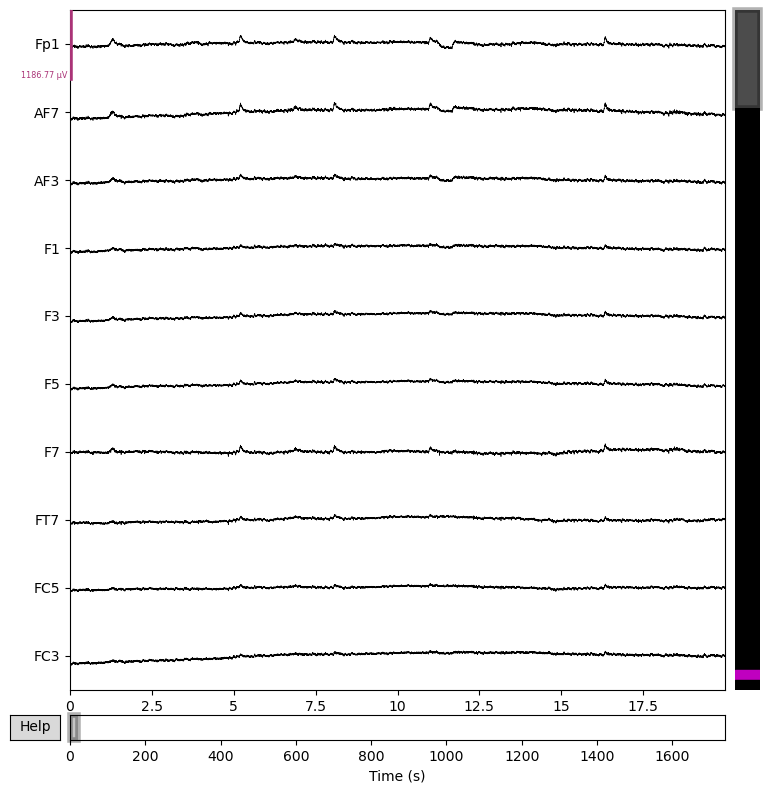

In [38]:
# For interactive scrolling and bad-channel marking, switch to:
%matplotlib qt
raw.plot(n_channels=10, duration=20, scalings="auto",
         title=f"sub-{SUBJECT} — Raw data (pre-filter)")

### Step 4b — Power Spectral Density (Pre-filtering)

The PSD reveals:

- **1/f slope** — the typical decrease of power with frequency
- **50 Hz peak** (and harmonics at 100 Hz) — power-line noise
- Any unusual spectral features (flat channels, broadband noise bursts)

This "before" snapshot will be compared to the post-pipeline PSD at the end.

/Users/arthurhsia/opt/anaconda3/envs/mne/lib/python3.13/site-packages/mne/viz/utils.py:160: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  (fig or plt).show(**kwargs)


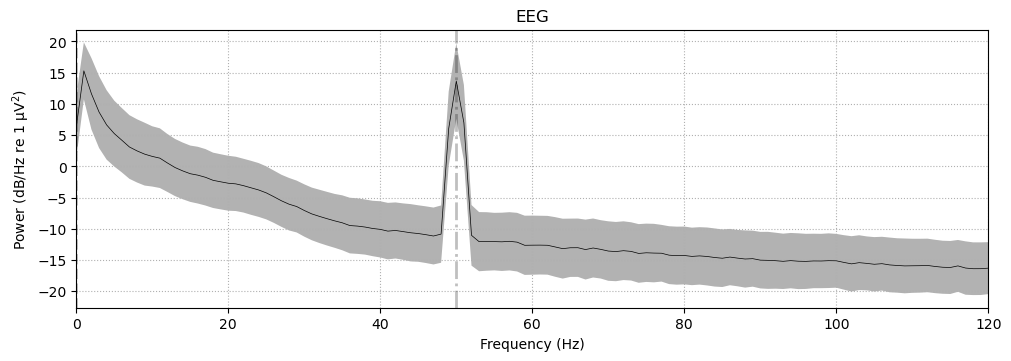

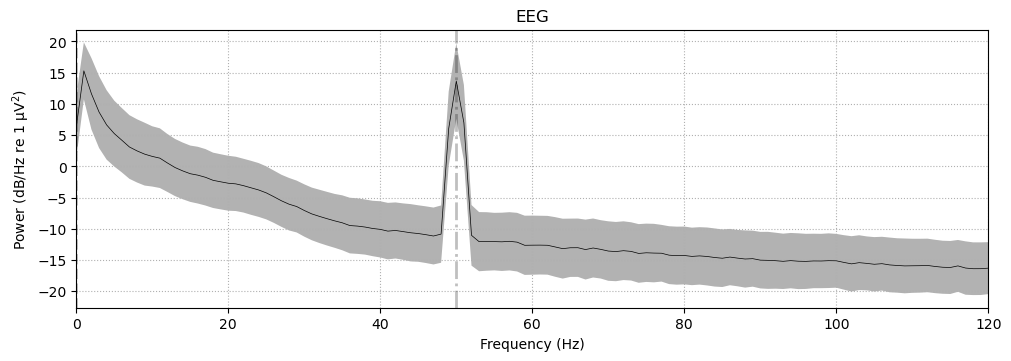

In [39]:
%matplotlib inline
raw.compute_psd(fmax=120).plot(average=True)

---
## Step 5 — Notch Filter (50 / 100 Hz)

European mains electricity oscillates at 50 Hz, creating sharp spectral
peaks at 50 Hz and its harmonic at 100 Hz. The **notch filter** removes
these narrowband artifacts without substantially affecting surrounding
frequencies.

MNE's default notch uses an FIR (finite impulse response) design. An
alternative is `method='spectrum_fit'` (similar to the CleanLine approach)
which fits and subtracts sinusoids.

Applied notch filter at [50, 100] Hz


/Users/arthurhsia/opt/anaconda3/envs/mne/lib/python3.13/site-packages/mne/viz/utils.py:160: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  (fig or plt).show(**kwargs)


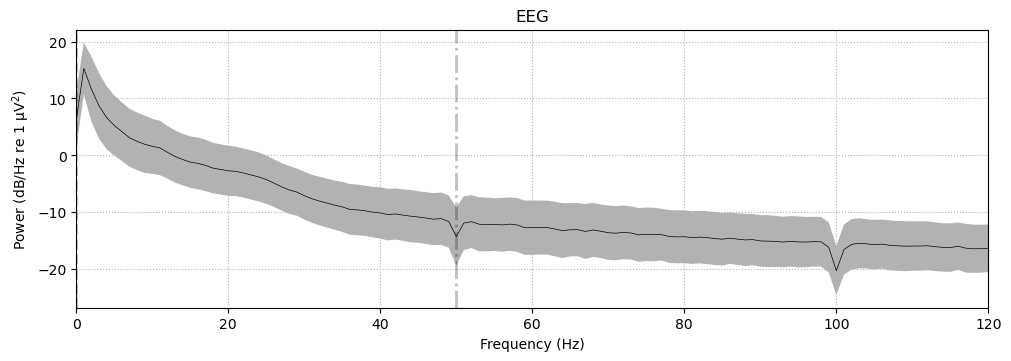

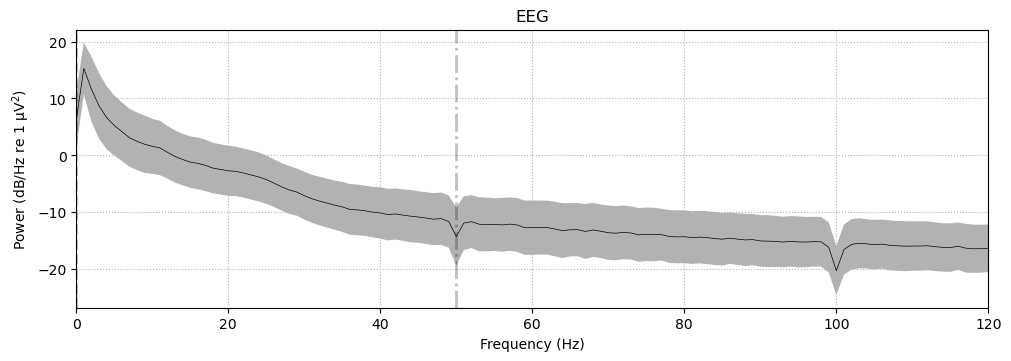

In [40]:
raw.notch_filter(np.array(NOTCH_FREQS, dtype=float), verbose=False)
print(f"Applied notch filter at {NOTCH_FREQS} Hz")

# Re-plot PSD to confirm line-noise removal
raw.compute_psd(fmax=120).plot(average=True)

---
## Step 6 — Detect Bad Channels

Bad channels are identified using a simple two-rule heuristic:

| Rule | Criterion | Interpretation |
|------|-----------|----------------|
| **Flat** | std < 1 µV | Disconnected or bridged electrode |
| **Noisy** | std > 5 × median | Excessive noise (movement, poor contact) |

These automatic detections are merged with any channels you marked manually
during `raw.plot()` above. Bad channels are **excluded from ICA fitting**
(so ICA does not waste a component modelling bad-channel noise) and
**interpolated later** (after ICA has been applied).

In [41]:
# Auto-detect flat and noisy EEG channels
picks_eeg = mne.pick_types(raw.info, eeg=True, exclude=[])
data = raw.get_data(picks=picks_eeg)
ch_names_eeg = [raw.ch_names[i] for i in picks_eeg]

stds = np.std(data, axis=1)
median_std = np.median(stds)

auto_bads = []
for i, name in enumerate(ch_names_eeg):
    if stds[i] < 1e-6:
        auto_bads.append(name)
        print(f"  FLAT  : {name}  (std = {stds[i]:.2e} V)")
    elif stds[i] > 5 * median_std:
        auto_bads.append(name)
        print(f"  NOISY : {name}  (std = {stds[i]:.2e} V, "
              f"median = {median_std:.2e} V)")

# Merge with any manual marks from raw.plot()
existing_bads = list(raw.info["bads"])
all_bads = sorted(set(auto_bads + existing_bads))
raw.info["bads"] = all_bads

if all_bads:
    print(f"\nBad channels ({len(all_bads)}): {all_bads}")
else:
    print("\nNo bad channels detected.")


Bad channels (4): [np.str_('P2'), np.str_('PO4'), np.str_('POz'), np.str_('Pz')]


---
## Step 7 — Two-Stream Bandpass Filtering

We create **two copies** of the notch-filtered data, each filtered with a
different high-pass cutoff:

| Stream | Band | Purpose |
|--------|------|---------|
| `raw_erp` | 0.1 – 40 Hz | Preserves slow ERP components (P3, CNV, LPP) |
| `raw_ica` | 1.0 – 40 Hz | Removes slow drifts that degrade ICA decomposition |

The ICA unmixing matrix is a **spatial transform** (a matrix multiply in
channel space). It does not depend on the temporal filter, so weights
estimated on `raw_ica` can be validly applied to `raw_erp` later.

The Status (stim) channel is unaffected by `filter()` — MNE skips
non-data channels automatically.

In [42]:
print("Creating two filtered copies ...")
raw_erp = raw.copy().filter(
    l_freq=ERP_L_FREQ, h_freq=ERP_H_FREQ, verbose=False
)
raw_ica = raw.copy().filter(
    l_freq=ICA_L_FREQ, h_freq=ICA_H_FREQ, verbose=False
)
del raw  # free memory — original is no longer needed

print(f"  raw_erp : {ERP_L_FREQ}–{ERP_H_FREQ} Hz  "
      f"(sfreq = {raw_erp.info['sfreq']:.0f} Hz)")
print(f"  raw_ica : {ICA_L_FREQ}–{ICA_H_FREQ} Hz  "
      f"(sfreq = {raw_ica.info['sfreq']:.0f} Hz)")

Creating two filtered copies ...
  raw_erp : 0.1–40.0 Hz  (sfreq = 2048 Hz)
  raw_ica : 1.0–40.0 Hz  (sfreq = 2048 Hz)


---
## Step 8 — Resample to 256 Hz (Optional)

BioSemi typically records at 2048 Hz (or 1024 / 4096 / 8192 Hz), which far
exceeds what is needed after low-passing at 40 Hz (Nyquist = 128 Hz).
Downsampling to **256 Hz** reduces data volume by roughly 8× and speeds up
ICA fitting proportionally.

MNE's `resample()` automatically applies an anti-aliasing low-pass filter
before decimation. The Status (stim) channel is downsampled via zero-order
hold, which preserves trigger values for well-separated events.

Set `RESAMPLE_SFREQ = None` in the Parameters cell to skip this step.

In [43]:
if RESAMPLE_SFREQ is not None and raw_erp.info["sfreq"] != RESAMPLE_SFREQ:
    original_sfreq = raw_erp.info["sfreq"]
    raw_erp.resample(RESAMPLE_SFREQ, verbose=False)
    raw_ica.resample(RESAMPLE_SFREQ, verbose=False)
    print(f"Resampled {original_sfreq:.0f} -> {RESAMPLE_SFREQ} Hz")
else:
    print(f"Resampling skipped (already at {raw_erp.info['sfreq']:.0f} Hz "
          f"or disabled)")

Resampled 2048 -> 256 Hz


---
## Step 9 — Fit ICA on the 1 Hz-Filtered Stream

**Independent Component Analysis (ICA)** decomposes the multi-channel EEG
into a set of maximally statistically independent source signals
("components"). Artifact sources — blinks, saccades, heartbeat — tend to
be spatially and temporally distinct from neural activity and concentrate
into one or two components that can be identified and removed.

Key settings:

| Parameter | Value | Rationale |
|-----------|-------|-----------|
| `n_components` | 0.99 | Retain PCA components explaining 99% of variance before ICA |
| `method` | `fastica` | Fastest standard algorithm; alternatives: `infomax`, `picard` |
| `random_state` | 42 | Reproducibility |

ICA is fit on `raw_ica` (1 Hz high-pass) because slow drifts inflate
variance and produce unstable decompositions. The resulting unmixing matrix
will be applied to `raw_erp` (0.1 Hz) in Step 11.

**Mastoid exclusion:** When `ICA_EXCLUDE_MASTOIDS = True`, the mastoid
channels (EXG1 / EXG2) are excluded from the ICA fit. Mastoid signals are
dominated by reference-related variance and rarely contain useful
information for artifact separation. Including them can waste a component
on mastoid noise.

In [44]:
ica = ICA(
    n_components=ICA_N_COMPONENTS,
    method=ICA_METHOD,
    random_state=ICA_RANDOM_STATE,
    max_iter=ICA_MAX_ITER,
)

# Build ICA picks — optionally exclude mastoid channels
if ICA_EXCLUDE_MASTOIDS:
    eeg_picks = mne.pick_types(raw_ica.info, eeg=True, exclude="bads")
    ica_picks = [p for p in eeg_picks
                 if raw_ica.ch_names[p] not in MASTOID_CHANNELS]
    excluded = [ch for ch in MASTOID_CHANNELS if ch in raw_ica.ch_names]
    print(f"Excluding mastoids from ICA: {excluded}")
else:
    ica_picks = "eeg"

ica.fit(raw_ica, picks=ica_picks, verbose=False)

print(f"ICA fitted: {ica.n_components_} components "
      f"(from {ICA_N_COMPONENTS} variance threshold)")

Excluding mastoids from ICA: ['EXG1', 'EXG2']
ICA fitted: 28 components (from 0.99 variance threshold)


In [45]:
eog_idx, eog_scores = [], np.array([])
ecg_idx, ecg_scores = [], np.array([])

# Detect EOG components using the bipolar EOG channel
if BIPOLAR_EOG_NAME in raw_ica.ch_names:
    eog_idx, eog_scores = ica.find_bads_eog(
        raw_ica, ch_name=BIPOLAR_EOG_NAME, verbose=False
    )
    print(f"EOG components (via {BIPOLAR_EOG_NAME}): {eog_idx}")
else:
    print(f"{BIPOLAR_EOG_NAME} not found — skipping blink detection")


# Detect ECG components using the bipolar ECG channel
if BIPOLAR_ECG_NAME in raw_ica.ch_names:
    ecg_idx, ecg_scores = ica.find_bads_ecg(
        raw_ica, ch_name=BIPOLAR_ECG_NAME, verbose=False
    )
    print(f"ECG components (via {BIPOLAR_ECG_NAME}): {ecg_idx}")
else:
    print(f"{BIPOLAR_ECG_NAME} not found — skipping cardiac detection")

ica.exclude = sorted(set(eog_idx + ecg_idx))
print(f"\nComponents to exclude ({len(ica.exclude)}): {ica.exclude}")

if len(ica.exclude) > 0.3 * ica.n_components_:
    print(f"WARNING: Excluding {len(ica.exclude)}/{ica.n_components_} "
          f"components — consider manual review")

EOG components (via EOG_bipolar): [np.int64(0), np.int64(5)]
ECG components (via ECG_bipolar): []

Components to exclude (2): [np.int64(0), np.int64(5)]


### Step 10b — Visualize ICA Components

Three complementary views help you verify the automatic detection:

1. **Scores** — bar chart of correlation between each component and the
   EOG / ECG reference. Flagged components should have the highest bars.
2. **Topographies** — spatial maps of the first 20 components. Blink
   components show a strong frontal focus; cardiac components show a
   regular left-right pattern.
3. **Properties** — for each excluded component: topography, time-course
   variance, and power spectrum. A true blink component has a low-frequency
   power peak and frontal projection.

After reviewing, you can manually adjust `ica.exclude` (add or remove
component indices) before running the next cell.

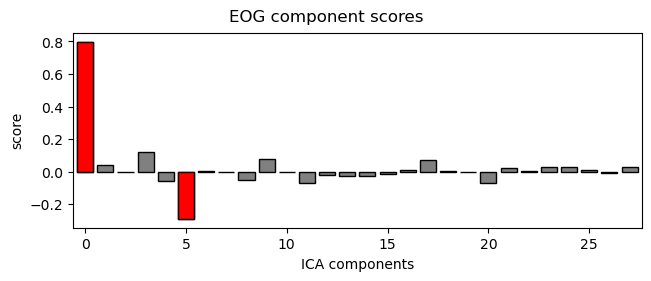

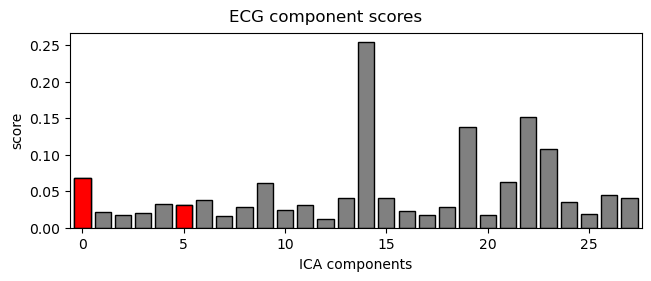

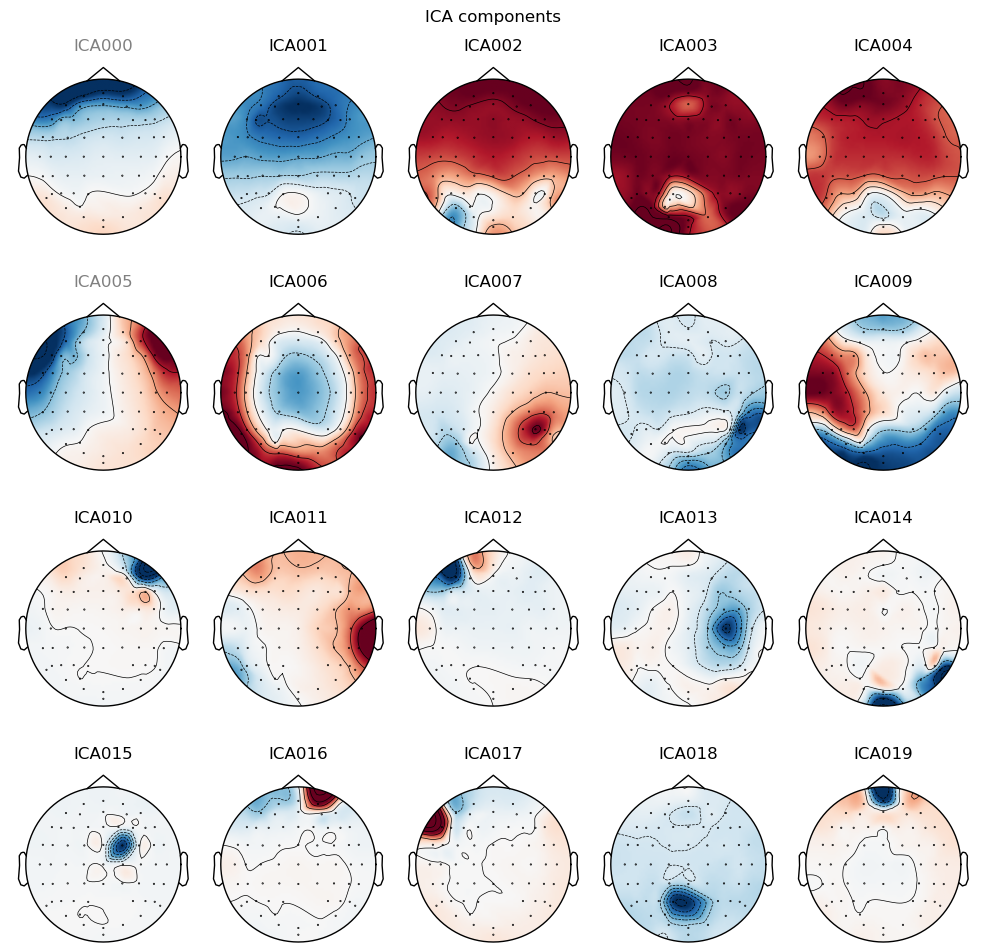

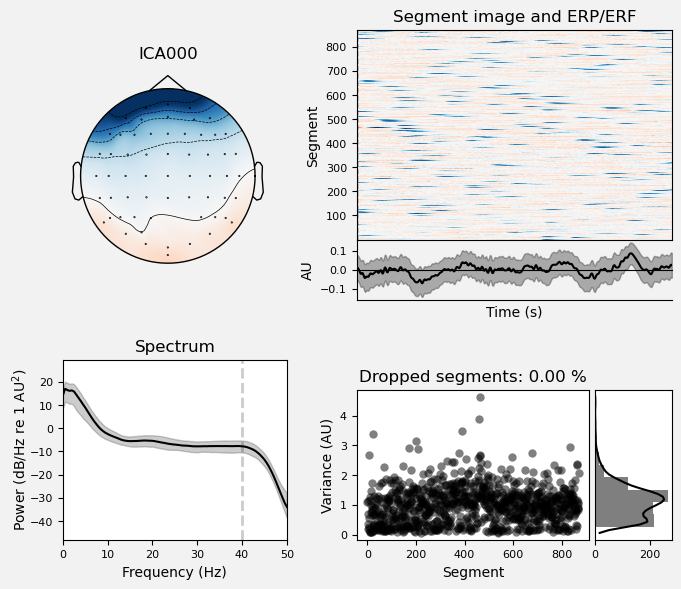

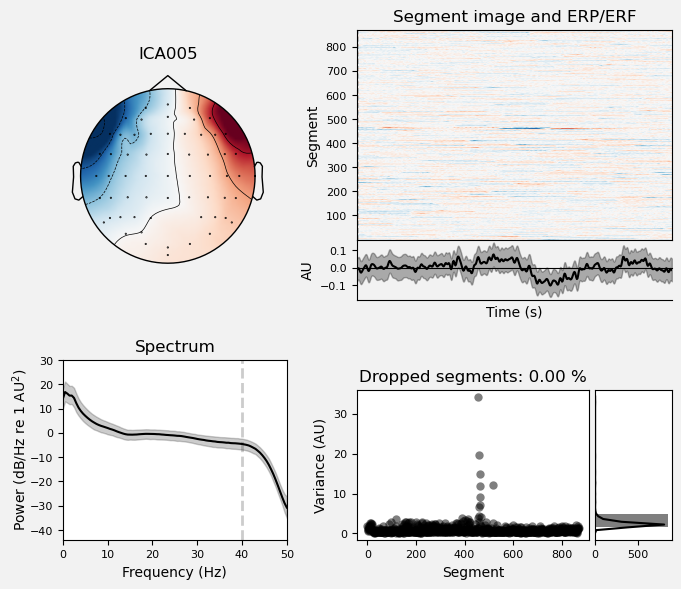

In [46]:
%matplotlib inline
# 1. Correlation scores
if len(eog_scores) > 0:
    ica.plot_scores(eog_scores, title="EOG component scores")
if len(ecg_scores) > 0:
    ica.plot_scores(ecg_scores, title="ECG component scores")

# 2. Component topographies (first 20 or fewer)
n_show = min(20, ica.n_components_)
ica.plot_components(picks=range(n_show))

# 3. Detailed properties of excluded components
if ica.exclude:
    ica.plot_properties(raw_ica, picks=ica.exclude)

In [47]:
# ----- Manual override (edit if needed) -----
# After reviewing the plots above, uncomment and edit to adjust:
# ica.exclude = [0, 1]   # replace with your chosen component indices
print(f"Final ICA exclusions: {ica.exclude}")

Final ICA exclusions: [np.int64(0), np.int64(5)]


---
## Step 11 — Apply ICA to the ERP Stream

The ICA unmixing matrix learned on `raw_ica` (1 Hz high-pass) is a purely
**spatial** operation — a matrix multiply in channel space. It does not
depend on the temporal filter settings, so it is valid to apply to
`raw_erp` (0.1 Hz high-pass).

Calling `ica.apply()` subtracts the excluded components from the ERP
stream, removing blink and cardiac contributions while preserving neural
activity.

After application, `raw_ica` is deleted to free memory.

In [48]:
ica.apply(raw_erp, verbose=False)
print(f"Applied ICA: removed {len(ica.exclude)} component(s) from ERP stream")

del raw_ica  # no longer needed

Applied ICA: removed 2 component(s) from ERP stream


---
## Step 12 — Interpolate Bad Channels and Set Reference

Bad channels were marked in Step 6 and excluded from ICA fitting. Now that
ICA artifact removal is complete, we **interpolate** them using spherical
splines (weighted average of surrounding channels based on their scalp
geometry).

Interpolation must happen **before** re-referencing, because a bad channel
would corrupt the reference computation.

After interpolation, `reset_bads=True` clears the bad list. Then we set the
**reference** according to the `REFERENCE` parameter:

| Option | Method | Notes |
|--------|--------|-------|
| `"average"` | Average of all EEG channels | Reference-free; standard for ERP analysis. Default. |
| `"mastoids"` | Mean of EXG1 + EXG2 | Linked-mastoid reference. Mastoid channels become flat after re-referencing and are dropped. |

Set `REFERENCE` in the Parameters cell.

In [49]:
# -----------------------------
# 1) (Optional but recommended) Montage sanity check
# -----------------------------
# Interpolation requires valid sensor positions. If you haven't set a montage yet, do it BEFORE this cell.
if raw_erp.get_montage() is None or not raw_erp.info.get("dig"):
    raise RuntimeError(
        "No montage / digitization info found. "
        "Set a montage (e.g., biosemi64) BEFORE interpolating bad channels."
    )

# -----------------------------
# 2) Interpolate bad channels (KEEP the bads list for QC)
#    IMPORTANT: exclude mastoids (often lack montage positions) from interpolation
# -----------------------------
exclude_from_interp = [ch for ch in MASTOID_CHANNELS if ch in raw_erp.ch_names]

if raw_erp.info["bads"]:
    print(
        f"Interpolating {len(raw_erp.info['bads'])} bad channel(s): {raw_erp.info['bads']}"
    )
    if exclude_from_interp:
        print(
            f"Excluding from interpolation (no scalp positions expected): {exclude_from_interp}"
        )
    raw_erp.interpolate_bads(
        reset_bads=False, exclude=exclude_from_interp, verbose=False
    )
else:
    print("No bad channels to interpolate")

# -----------------------------
# 3) Re-reference
# -----------------------------
if REFERENCE == "average":
    # Average reference across scalp EEG only.
    # IMPORTANT: do not include stim/EOG/ECG channels (e.g., Status),
    # and exclude mastoids from the average reference pool.
    eeg_names = [
        raw_erp.ch_names[p]
        for p in mne.pick_types(
            raw_erp.info,
            eeg=True,
            eog=False,
            ecg=False,
            stim=False,
            exclude=[],
        )
    ]
    ref_exclude = set(MASTOID_CHANNELS)
    scalp_eeg = [ch for ch in eeg_names if ch not in ref_exclude]

    # Sanity: ensure we have a reasonable number of scalp channels
    if len(scalp_eeg) < 32:
        raise RuntimeError(
            f"Too few channels for scalp average reference ({len(scalp_eeg)}). "
            f"Check channel names and MASTOID_CHANNELS={MASTOID_CHANNELS}."
        )

    raw_erp.set_eeg_reference(ref_channels=scalp_eeg, verbose=False)
    print(
        f"Set average reference using {len(scalp_eeg)} scalp EEG channels "
        f"(excluded mastoids: {sorted(ref_exclude.intersection(eeg_names))})."
    )

elif REFERENCE == "mastoids":
    ref_chs = [ch for ch in MASTOID_CHANNELS if ch in raw_erp.ch_names]
    assert len(ref_chs) == 2, (
        f"Expected 2 mastoid channels, found {ref_chs} — "
        f"check MASTOID_CHANNELS and that they were not dropped earlier"
    )
    raw_erp.set_eeg_reference(ref_chs, verbose=False)
    print(
        f"Set linked-mastoid reference ({ref_chs}). (Keeping mastoid channels for QC/teaching.)"
    )

else:
    raise ValueError(
        f"Unknown REFERENCE value: {REFERENCE!r}. Use 'average' or 'mastoids'."
    )

# -----------------------------
# 4) Quick report
# -----------------------------
n_eeg = len(mne.pick_types(raw_erp.info, eeg=True, exclude=[]))
print(f"EEG channels after interpolation + re-reference: {n_eeg}")
print("Bad channels record (kept for QC):", raw_erp.info["bads"])

Interpolating 4 bad channel(s): [np.str_('P2'), np.str_('PO4'), np.str_('POz'), np.str_('Pz')]
Excluding from interpolation (no scalp positions expected): ['EXG1', 'EXG2']
Set average reference using 64 scalp EEG channels (excluded mastoids: ['EXG1', 'EXG2']).
EEG channels after interpolation + re-reference: 66
Bad channels record (kept for QC): [np.str_('P2'), np.str_('PO4'), np.str_('POz'), np.str_('Pz')]


In [50]:
# Convenience alias: from this point onward, `raw_erp_clean` refers to the cleaned continuous EEG
# (after ICA application, bad-channel interpolation, and re-referencing).
raw_erp_clean = raw_erp


---
## Step 12b — (Optional) Annotate Bad Time Segments in Continuous Data

Long task recordings often contain short periods of gross movement, cable tugs,
or electrode pops. These are best handled by **excluding the contaminated time
segments** in the continuous data rather than cherry-picking individual trials.

In MNE, you can add annotations whose description starts with **`BAD`**
(e.g., `BAD_movement`). When `REJECT_BY_ANNOTATION=True`, any epochs that overlap
a BAD annotation will be dropped automatically during epoching.

**How to annotate (interactive):**
1. Run the next cell to open the raw browser.
2. Drag to select a time span with gross artifact.
3. Press **`a`** to create an annotation and type a description beginning with `BAD`.
4. Close the browser window and continue.

If you do not want to annotate manually, set `RUN_MANUAL_ANNOTATION=False` in the
Parameters cell.


In [51]:
if RUN_MANUAL_ANNOTATION:
    # Use an interactive backend for best experience
    try:
        get_ipython().run_line_magic("matplotlib", "qt")
    except Exception:
        pass

    print("Open the raw browser. Create annotations with descriptions starting with 'BAD'.")
    raw_erp.plot(n_channels=40, duration=10, scalings="auto", block=True)

    n_bad = sum([desc.startswith("BAD") for desc in raw_erp.annotations.description])
    print(f"Current annotations: {len(raw_erp.annotations)} total; {n_bad} BAD annotations")
else:
    print("Skipping manual annotation (RUN_MANUAL_ANNOTATION=False).")


Skipping manual annotation (RUN_MANUAL_ANNOTATION=False).


---
## Step 13 — Extract Events from the BioSemi Status Channel

The BioSemi Status channel is a 24-bit word where:

- **Bits 0–15** encode the trigger value sent by the stimulus PC
- **Bits 16–23** carry system flags (battery low, CMS in range, etc.)

The mask `0x00FFFF` with `mask_type="and"` strips the upper 8 bits,
isolating the trigger code. `min_duration=0.002` (2 ms) suppresses
spurious sub-2 ms glitches that some BioSemi setups produce on trigger
onset/offset.

> **Note:** The Status channel is sometimes referred to as `STI 014` in
> MNE documentation. In BioSemi BDF files loaded with `read_raw_bdf()`,
> the channel is named `Status`.

In [52]:
# =========================
# Event extraction (BioSemi Status) + canonical outcome events (1 per trial)
# =========================
import numpy as np
import mne

raw_for_events = raw_erp_clean if 'raw_erp_clean' in globals() else raw_erp

if "Status" in raw_for_events.ch_names:
    events_all = mne.find_events(
        raw_for_events,
        stim_channel="Status",
        shortest_event=1,
        min_duration=0,
        mask=0x00FFFF,
        mask_type="and",
        verbose=False,
    )

    print(f"Raw events extracted: {len(events_all)} ({len(np.unique(events_all[:, 2]))} unique codes)")
    print("Unique event codes (first 80):", sorted(set(events_all[:, 2]))[:80])

    KEEP_CODES = {10, 17, 18, 19}  # start, loss, newTrial, reward
    events_task = events_all[np.isin(events_all[:, 2], list(KEEP_CODES))].copy()
    events_task = events_task[np.argsort(events_task[:, 0])]

    def _count(code):
        return int(np.sum(events_task[:, 2] == code))

    print("Counts (task-filtered):", {c: _count(c) for c in sorted(KEEP_CODES)})

    NEWTRIAL = 18
    OUTCOMES = {17, 19}

    new_pos = np.where(events_task[:, 2] == NEWTRIAL)[0]
    out_pos = np.where(np.isin(events_task[:, 2], list(OUTCOMES)))[0]

    n_trials = len(new_pos)
    print("newTrial:", n_trials)

    out_samples = events_task[out_pos, 0]
    out_codes   = events_task[out_pos, 2]

    canonical = []
    missing = 0

    for ii in range(n_trials):
        start_samp = events_task[new_pos[ii], 0]
        end_samp = events_task[new_pos[ii + 1], 0] if ii < (n_trials - 1) else np.inf

        j = np.searchsorted(out_samples, start_samp, side="left")
        if j < len(out_samples) and out_samples[j] < end_samp:
            canonical.append([int(out_samples[j]), 0, int(out_codes[j])])
        else:
            missing += 1

    events_outcome_first = np.array(canonical, dtype=int)
    print(f"Canonical outcomes (first per trial): {len(events_outcome_first)}")
    if missing:
        print(f"WARNING: {missing} trial(s) had no outcome found between newTrial boundaries.")

    print(
        "Canonical outcome counts:",
        {c: int(np.sum(events_outcome_first[:, 2] == c)) for c in sorted(OUTCOMES)}
    )

else:
    if "events_outcome_first" not in globals() or len(events_outcome_first) == 0:
        raise RuntimeError(
            "Status channel is missing and no cached events_outcome_first found. "
            "Re-run from Step 12/13 or restart kernel and run top-to-bottom."
        )
    print(
        "Status channel not present (likely dropped in Step 14). "
        "Reusing existing events_outcome_first from current session."
    )
    print(f"Cached canonical outcomes: {len(events_outcome_first)}")
    print(
        "Cached outcome counts:",
        {c: int(np.sum(events_outcome_first[:, 2] == c)) for c in sorted(set(events_outcome_first[:, 2]))}
    )

event_id = {"loss": 17, "reward": 19}

Raw events extracted: 3599 (8 unique codes)
Unique event codes (first 80): [np.int64(10), np.int64(12), np.int64(13), np.int64(14), np.int64(15), np.int64(17), np.int64(18), np.int64(19)]
Counts (task-filtered): {10: 3, 17: 525, 18: 720, 19: 459}
newTrial: 720
Canonical outcomes (first per trial): 719
Canonical outcome counts: {17: 262, 19: 457}


---
## Step 14 — Define Event-ID Mapping and Select Outcome Events

The `EVENT_ID` dictionary maps human-readable event names to integer trigger codes.
Only events whose codes appear in this dictionary are retained; all others are discarded.

For this task, the relevant outcome events are:

- **Loss:** `game.ballExplode` (code 17)
- **Reward:** `game.asteroidTail` (code 19)

We select these outcome events for epoching. (Other triggers like hits/misses can still
be kept in `EVENT_ID` for QC or later use, but they are not used for epoching here.)

After event extraction, the Status channel is dropped (no longer needed).


In [53]:
# Filter to known event codes
known_codes = set(EVENT_ID.values())
keep_mask = np.isin(events_outcome_first[:, 2], list(known_codes))
events = events_outcome_first[keep_mask]

code_to_name = {v: k for k, v in EVENT_ID.items()}
print(f"After filtering to known codes: {len(events)} events")
for code in sorted(np.unique(events[:, 2])):
    n = np.sum(events[:, 2] == code)
    print(f"  {code_to_name.get(code, f'unknown_{code}'):>16s} "
          f"(code {code}): {n}")

# Select outcome events for epoching (supports renamed labels via aliases)
EVENT_NAME_ALIASES = {
    "game.loss": "game.ballExplode",
    "game.reward": "game.asteroidTail",
    "loss": "game.ballExplode",
    "reward": "game.asteroidTail",
}

resolved_outcome_names = []
missing_names = []
for requested_name in OUTCOME_EVENT_NAMES:
    if requested_name in EVENT_ID:
        resolved_outcome_names.append(requested_name)
    else:
        alias_target = EVENT_NAME_ALIASES.get(requested_name)
        if alias_target in EVENT_ID:
            resolved_outcome_names.append(alias_target)
        else:
            missing_names.append(requested_name)

if missing_names:
    available = sorted(EVENT_ID.keys())
    raise KeyError(
        f"Unknown outcome event name(s): {missing_names}. "
        f"Available EVENT_ID keys include: {available}"
    )

outcome_codes = [EVENT_ID[name] for name in resolved_outcome_names]
outcome_mask = np.isin(events[:, 2], outcome_codes)
outcome_events = events[outcome_mask]

print("\nOutcome events selected for epoching:")
for requested_name, resolved_name in zip(OUTCOME_EVENT_NAMES, resolved_outcome_names):
    code = EVENT_ID[resolved_name]
    n = np.sum(outcome_events[:, 2] == code)
    if requested_name == resolved_name:
        print(f"  {requested_name:>16s} (code {code}): {n}")
    else:
        print(f"  {requested_name:>16s} -> {resolved_name} (code {code}): {n}")

assert len(outcome_events) > 0, (
    f"No outcome events found for {OUTCOME_EVENT_NAMES} — "
    "check EVENT_ID mapping and triggers in the file."
)

# Drop the Status channel (no longer needed)
stim_picks = mne.pick_types(raw_erp.info, stim=True, exclude=[])
stim_names = [raw_erp.ch_names[i] for i in stim_picks]
if stim_names:
    raw_erp.drop_channels(stim_names)
    print(f"Dropped stim channel(s): {stim_names}")


After filtering to known codes: 719 events
  game.ballExplode (code 17): 262
  game.asteroidTail (code 19): 457

Outcome events selected for epoching:
         game.loss -> game.ballExplode (code 17): 262
       game.reward -> game.asteroidTail (code 19): 457
Dropped stim channel(s): ['Status']


---
## Step 15 — Attach Behavioural Metadata

If a behavioural log file (CSV or TSV) is available, we load it and align it
to the **outcome triggers**. The alignment is **positional**: row 1 in the
behavioural file corresponds to the 1st outcome event in the EEG (either loss
or reward), row 2 to the 2nd, and so on.

A count check verifies that the number of outcome events matches the number
of behavioural rows. If there is a mismatch (e.g., the recording was stopped
early), a warning is printed and the shorter length is used.

The metadata DataFrame is passed to `mne.Epochs(metadata=...)` so that trial-wise
variables stay synchronized with epochs through any subsequent rejection steps.


In [54]:
metadata = None

# For this task, assume one outcome trigger (reward OR loss) per trial.
# We align behavioural rows to the chronological order of outcome events.
if behav_path is not None:
    sep = "\t" if behav_path.suffix == ".tsv" else ","
    behav_df = pd.read_csv(behav_path, sep=sep)

    n_events = len(outcome_events)
    n_behav  = len(behav_df)

    if n_events != n_behav:
        print(f"WARNING: Trial count mismatch: {n_events} outcome events vs "
              f"{n_behav} behavioural rows — truncating to shorter")
        n = min(n_events, n_behav)
        outcome_events = outcome_events[:n]
        behav_df = behav_df.iloc[:n]
    else:
        print(f"Trial alignment OK: {n_events} events == {n_behav} rows")

    metadata = behav_df.copy()
    metadata["eeg_onset"]  = outcome_events[:, 0] / raw_erp.info["sfreq"]
    metadata["eeg_sample"] = outcome_events[:, 0]
    metadata["eeg_code"]   = outcome_events[:, 2]
    metadata["eeg_event"]  = [code_to_name.get(c, f"unknown_{c}") for c in outcome_events[:, 2]]

    print(f"Metadata: {len(metadata)} trials x {len(metadata.columns)} columns")
    print(f"Columns: {list(metadata.columns)}")
else:
    print("No behavioural file found — epochs will be created without metadata")


UnicodeDecodeError: 'utf-8' codec can't decode byte 0x90 in position 22: invalid start byte

---
## Step 16 — Create Outcome-Locked Epochs

Epochs are segments of continuous data time-locked to an event of interest.
Here we time-lock to **outcome events**:

- `game.ballExplode` (loss)
- `game.asteroidTail` (reward)

Each epoch spans from `EPOCH_TMIN` (e.g., −0.2 s) to `EPOCH_TMAX` (e.g., +0.8 s).

**Baseline correction** subtracts the mean voltage during the pre-event
window (`BASELINE`, typically −0.2 to 0 s) from the entire epoch, removing any
residual DC offset.

Epochs are created here **without** automatic artifact rejection (`reject=None`) so
that the rejection step is a separate, visible cell. If `REJECT_BY_ANNOTATION=True`,
epochs overlapping BAD annotations (Step 12b) are dropped automatically at construction.


In [55]:
# =========================
# Epoching: outcome-locked (canonical 1 outcome per trial)
# =========================
import mne
import numpy as np

assert 'events_outcome_first' in globals(), "Run the canonical event extraction cell first."
assert 'event_id' in globals(), "event_id should be defined in the canonical event extraction cell."
RESP_ID = 12

# events_all: original events (sample, 0, code)
events_response = events_all[events_all[:, 2] == RESP_ID]

event_id_resp = {"game.response": RESP_ID}
epochs_fb = mne.Epochs(
    raw_erp_clean,
    events_outcome_first,
    event_id=event_id_resp,
    tmin=EPOCH_TMIN,
    tmax=EPOCH_TMAX,
    baseline=BASELINE,
    preload=True,
    reject_by_annotation=REJECT_BY_ANNOTATION,
    verbose=False,
)

print("Epochs created:", len(epochs_fb))
print("Epoch counts by condition:", {k: len(epochs_fb[k]) for k in epochs_fb.event_id})

# -------------------------
# Objective epoch-level rejection (post-ICA, post-reference)
# -------------------------
reject = dict(eeg=REJECT_EEG)
flat   = dict(eeg=REJECT_FLAT_EEG)

epochs_fb_clean = epochs_fb.copy()
epochs_fb_clean.drop_bad(reject=reject, flat=flat)

n_total   = len(epochs_fb_clean.drop_log)
n_kept    = len(epochs_fb_clean)
n_dropped = n_total - n_kept
pct       = (n_dropped / n_total * 100) if n_total > 0 else 0.0

print("Epoch rejection:")
print(f"  peak-to-peak EEG : {REJECT_EEG * 1e6:.0f} µV")
print(f"  flat EEG         : {REJECT_FLAT_EEG * 1e6:.0f} µV")
print(f"  Retained         : {n_kept} / {n_total}  ({100 - pct:.1f}%)")
print(f"  Dropped          : {n_dropped} / {n_total}  ({pct:.1f}%)")

from collections import Counter
reasons = []
for r in epochs_fb_clean.drop_log:
    if len(r) > 0:
        reasons.extend(list(r))
print("Top drop reasons:", Counter(reasons).most_common(8))

if len(epochs_fb_clean) == 0:
    print(
        "WARNING: All epochs were dropped. This usually means one or more channels are consistently noisy.\n"
        "Next steps:\n"
        "  1) epochs_fb.plot_drop_log() to see culprit channels\n"
        "  2) Mark those channels as bad in raw_erp_clean.info['bads'], interpolate again, then recreate epochs\n"
        "  3) Or relax REJECT_EEG temporarily for QC (not ideal long-term)\n"
    )


ValueError: No matching events found for game.response (event id 12)

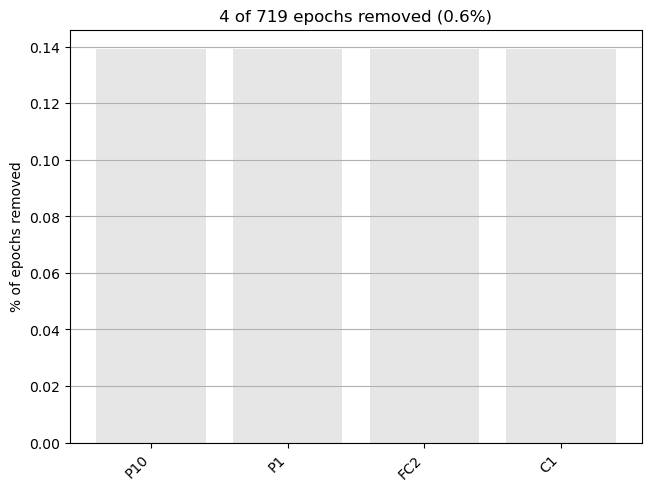

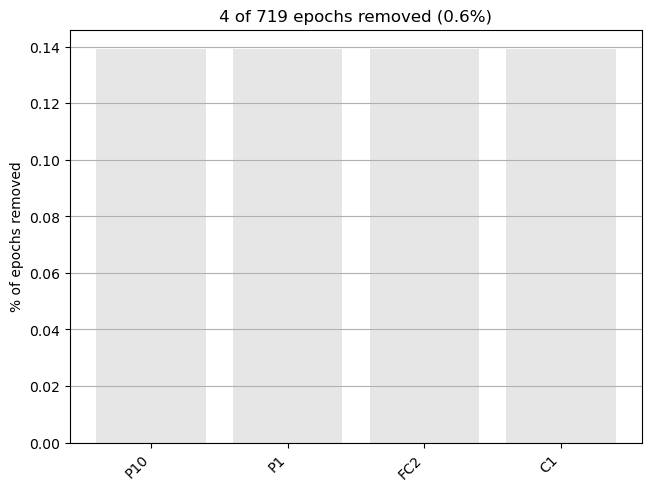

In [56]:
epochs_fb_clean.plot_drop_log()


In [57]:
# Helper: if many epochs drop, identify channels that exceed threshold in most epochs
import numpy as np
import mne

if 'epochs_fb' in globals() and len(epochs_fb) > 0:
    eeg_picks = mne.pick_types(epochs_fb.info, eeg=True, exclude=[])
    data = epochs_fb.get_data(picks=eeg_picks)  # Volts
    ptp = np.ptp(data, axis=2)  # (n_epochs, n_ch)
    frac = np.mean(ptp > REJECT_EEG, axis=0)

    ch_names = [epochs_fb.ch_names[i] for i in eeg_picks]
    worst = sorted(zip(ch_names, frac), key=lambda x: x[1], reverse=True)[:15]
    print("Top channels by fraction of epochs exceeding REJECT_EEG:")
    for ch, f in worst:
        print(f"  {ch:>6s}: {100*f:5.1f}%")
else:
    print("epochs_fb not available yet.")


Top channels by fraction of epochs exceeding REJECT_EEG:
      C1:   0.1%
      P1:   0.1%
     FC2:   0.1%
     P10:   0.1%
     Fp1:   0.0%
     AF7:   0.0%
     AF3:   0.0%
      F1:   0.0%
      F3:   0.0%
      F5:   0.0%
      F7:   0.0%
     FT7:   0.0%
     FC5:   0.0%
     FC3:   0.0%
     FC1:   0.0%


---
## Step 17 — Drop Bad Epochs (Peak-to-Peak Threshold)

Any epoch where the **peak-to-peak amplitude** on any EEG channel exceeds
the threshold is dropped. This removes epochs contaminated by residual
muscle artifacts, electrode pops, or movement.

| Channel type | Threshold | Rationale |
|-------------|-----------|----------|
| EEG | 150 µV | Conservative default; catches gross artifacts |

The drop log shows which epochs were removed and why. If the retention rate
is below ~70%, consider relaxing the threshold, improving data quality, or
using a data-driven method such as `autoreject`.

Note: `epochs.metadata` is automatically trimmed to match surviving epochs.

In [58]:
# Objective epoch-level rejection (post-ICA, post-reference)
# Peak-to-peak catches residual movement / electrode pops; flat catches dropouts.
reject = dict(eeg=REJECT_EEG)
flat   = dict(eeg=REJECT_FLAT_EEG)

# Work on a COPY so we keep `epochs_fb` (before) for QC diagnostics
epochs_fb_clean = epochs_fb.copy()
epochs_fb_clean.drop_bad(reject=reject, flat=flat)

n_total   = len(epochs_fb_clean.drop_log)
n_kept    = len(epochs_fb_clean)
n_dropped = n_total - n_kept
pct       = (n_dropped / n_total * 100) if n_total > 0 else 0.0

print("Epoch rejection:")
print(f"  peak-to-peak EEG : {REJECT_EEG * 1e6:.0f} µV")
print(f"  flat EEG         : {REJECT_FLAT_EEG * 1e6:.0f} µV")
print(f"  Retained         : {n_kept} / {n_total}  ({100 - pct:.1f}%)")
print(f"  Dropped          : {n_dropped} / {n_total}  ({pct:.1f}%)")

# Show top rejection reasons (quick QC)
from collections import Counter
reasons = []
for r in epochs_fb_clean.drop_log:
    if len(r) > 0:
        reasons.extend(list(r))
print("Top drop reasons:", Counter(reasons).most_common(8))


Epoch rejection:
  peak-to-peak EEG : 150 µV
  flat EEG         : 1 µV
  Retained         : 715 / 719  (99.4%)
  Dropped          : 4 / 719  (0.6%)
Top drop reasons: [('C1', 1), ('FC2', 1), ('P1', 1), ('P10', 1)]


---
## Step 18 — Save Cleaned Data

Four files are saved to `data/derivatives/mne_preproc/sub-XX/ses-XX/`:

| File | Description |
|------|-------------|
| `*_raw_clean.fif` | Cleaned continuous data (ICA + interpolation + avg ref, before epoching). Useful for re-epoching to different events. |
| `*_ica.fif` | Fitted ICA object with excluded components marked. Enables re-application or review. |
| `*_epochs_feedback_clean-epo.fif` | Final cleaned, baseline-corrected epochs with behavioural metadata. Ready for ERP analysis. |
| `*_qc_summary.json` | Machine-readable QC metrics (bad channels, ICA exclusions, epoch counts). |

In [59]:
prefix = f"sub-{SUBJECT}_ses-{SESSION}_task-{TASK}"

# 1. Cleaned continuous data
raw_clean_path = out_dir / f"{prefix}_raw_clean.fif"
raw_erp.save(raw_clean_path, overwrite=True, verbose=False)
print(f"Saved: {raw_clean_path}")

# 2. ICA solution
ica_path = out_dir / f"{prefix}_ica.fif"
ica.save(ica_path, overwrite=True)
print(f"Saved: {ica_path}")

# 3. Cleaned epochs
epochs_path = out_dir / f"{prefix}_epochs_feedback_clean-epo.fif"
epochs_to_save = epochs_fb_clean if "epochs_fb_clean" in globals() else epochs_fb
epochs_to_save.save(epochs_path, overwrite=True, verbose=False)
print(f"Saved: {epochs_path} (n={len(epochs_to_save)} epochs)")

/var/folders/bg/35xhpjxn5mn8n4n2k4h8pc8w0000gn/T/ipykernel_45511/3101933856.py:5: RuntimeWarning: This filename (/Users/arthurhsia/Desktop/Psychology/EEG/data/derivatives/mne_preproc/sub-01/ses-01/sub-01_ses-01_task-Cannonball MF_raw_clean.fif) does not conform to MNE naming conventions. All raw files should end with raw.fif, raw_sss.fif, raw_tsss.fif, _meg.fif, _eeg.fif, _ieeg.fif, raw.fif.gz, raw_sss.fif.gz, raw_tsss.fif.gz, _meg.fif.gz, _eeg.fif.gz or _ieeg.fif.gz
  raw_erp.save(raw_clean_path, overwrite=True, verbose=False)


Saved: /Users/arthurhsia/Desktop/Psychology/EEG/data/derivatives/mne_preproc/sub-01/ses-01/sub-01_ses-01_task-Cannonball MF_raw_clean.fif
Saved: /Users/arthurhsia/Desktop/Psychology/EEG/data/derivatives/mne_preproc/sub-01/ses-01/sub-01_ses-01_task-Cannonball MF_ica.fif
Saved: /Users/arthurhsia/Desktop/Psychology/EEG/data/derivatives/mne_preproc/sub-01/ses-01/sub-01_ses-01_task-Cannonball MF_epochs_feedback_clean-epo.fif (n=715 epochs)


In [60]:
# ---------------------------------------------------------------------------
# Save outputs
# ---------------------------------------------------------------------------
from collections import Counter

if "prefix" not in globals():
    prefix = f"sub-{SUBJECT}_ses-{SESSION}_task-{TASK}"

epochs_to_save = epochs_fb_clean if "epochs_fb_clean" in globals() else epochs_fb

# 1. Cleaned continuous data (ERP stream after ICA, interpolation, reference)
raw_path = out_dir / f"{prefix}_desc-clean_raw.fif"
raw_erp.save(raw_path, overwrite=True)
print(f"Saved: {raw_path}")

# 2. ICA solution
ica_path = out_dir / f"{prefix}_desc-ica.fif"
ica.save(ica_path, overwrite=True)
print(f"Saved: {ica_path}")

# 3. Cleaned epochs
epo_path = out_dir / f"{prefix}_desc-outcome_clean-epo.fif"
epochs_to_save.save(epo_path, overwrite=True)
print(f"Saved: {epo_path}")

# 4. Keep a stable record of which epochs survived cleaning
sel_path = out_dir / f"{prefix}_kept_epoch_indices.npy"
np.save(sel_path, epochs_to_save.selection)
print(f"Saved: {sel_path} (epochs.selection; indices into the original event sequence)")

# 5. Robust epoch accounting
n_total_local = len(epochs_to_save.drop_log)
n_kept_local = len(epochs_to_save)
n_dropped_local = n_total_local - n_kept_local
pct_local = (n_dropped_local / n_total_local * 100) if n_total_local > 0 else 0.0

drop_reasons = []
for r in epochs_to_save.drop_log:
    if len(r) > 0:
        drop_reasons.extend(list(r))
reason_counts = Counter(drop_reasons)

# 6. QC summary (JSON)
n_bad_annot = sum([d.startswith("BAD") for d in raw_erp.annotations.description])
qc_summary = {
    "subject": str(SUBJECT),
    "session": str(SESSION),
    "task": str(TASK),
    "sfreq": float(raw_erp.info["sfreq"]),
    "reference": str(REFERENCE),
    "reject_by_annotation": bool(REJECT_BY_ANNOTATION),
    "n_bad_annotations": int(n_bad_annot),
    "outcome_events": [str(x) for x in OUTCOME_EVENT_NAMES],
    "n_channels_eeg": int(len(mne.pick_types(raw_erp.info, eeg=True, exclude=[]))),
    "n_channels_interpolated": int(len(all_bads)),
    "bad_channels": [str(ch) for ch in all_bads],
    "ica_exclude_mastoids": bool(ICA_EXCLUDE_MASTOIDS),
    "n_ica_components": int(ica.n_components_),
    "n_ica_excluded": int(len(ica.exclude)),
    "ica_excluded_idx": [int(x) for x in ica.exclude],
    "n_epochs_total": int(n_total_local),
    "n_epochs_kept": int(n_kept_local),
    "n_epochs_dropped": int(n_dropped_local),
    "percent_dropped": float(round(float(pct_local), 1)),
    "drop_reasons": {str(k): int(v) for k, v in reason_counts.items()},
    "epoch_tmin": float(EPOCH_TMIN),
    "epoch_tmax": float(EPOCH_TMAX),
    "baseline": [float(x) for x in BASELINE],
    "reject_eeg_uv": float(REJECT_EEG * 1e6),
    "flat_eeg_uv": float(REJECT_FLAT_EEG * 1e6),
}

qc_path = out_dir / f"{prefix}_qc_summary.json"
with open(qc_path, "w", encoding="utf-8") as fh:
    json.dump(qc_summary, fh, indent=2)
print(f"Saved: {qc_path}")

# Print summary
print(f"\n{'=' * 60}")
print(f"QC SUMMARY — sub-{SUBJECT} ses-{SESSION}")
print(f"{'=' * 60}")
for k, v in qc_summary.items():
    print(f"  {k:>28s} : {v}")
print(f"{'=' * 60}")


Saved: /Users/arthurhsia/Desktop/Psychology/EEG/data/derivatives/mne_preproc/sub-01/ses-01/sub-01_ses-01_task-Cannonball MF_desc-clean_raw.fif
Saved: /Users/arthurhsia/Desktop/Psychology/EEG/data/derivatives/mne_preproc/sub-01/ses-01/sub-01_ses-01_task-Cannonball MF_desc-ica.fif
Saved: /Users/arthurhsia/Desktop/Psychology/EEG/data/derivatives/mne_preproc/sub-01/ses-01/sub-01_ses-01_task-Cannonball MF_desc-outcome_clean-epo.fif
Saved: /Users/arthurhsia/Desktop/Psychology/EEG/data/derivatives/mne_preproc/sub-01/ses-01/sub-01_ses-01_task-Cannonball MF_kept_epoch_indices.npy (epochs.selection; indices into the original event sequence)
Saved: /Users/arthurhsia/Desktop/Psychology/EEG/data/derivatives/mne_preproc/sub-01/ses-01/sub-01_ses-01_task-Cannonball MF_qc_summary.json

QC SUMMARY — sub-01 ses-01
                       subject : 01
                       session : 01
                          task : Cannonball MF
                         sfreq : 256.0
                     reference : av

---
## Step 19 — Final QC Plots

These plots serve as a post-pipeline sanity check:

- **PSD** — should show no line noise, clean rolloff above 40 Hz, no
  unusual peaks
- **Epoch image** — a heat-map of single-trial amplitudes across time;
  look for systematic drift or high-amplitude outlier bands
- **Butterfly / ERP** — the grand-average waveform; a first look at the
  feedback-locked ERP morphology

/Users/arthurhsia/opt/anaconda3/envs/mne/lib/python3.13/site-packages/mne/viz/utils.py:160: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  (fig or plt).show(**kwargs)


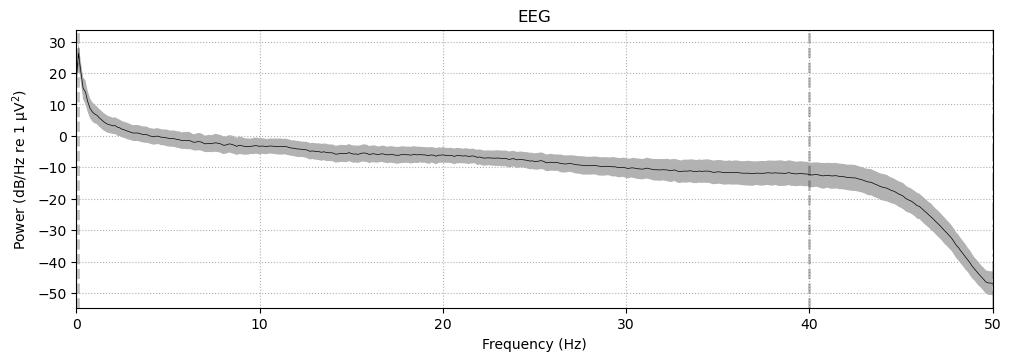

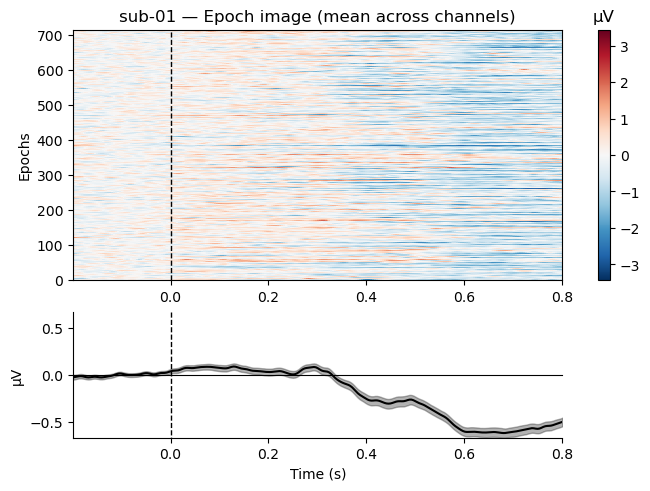

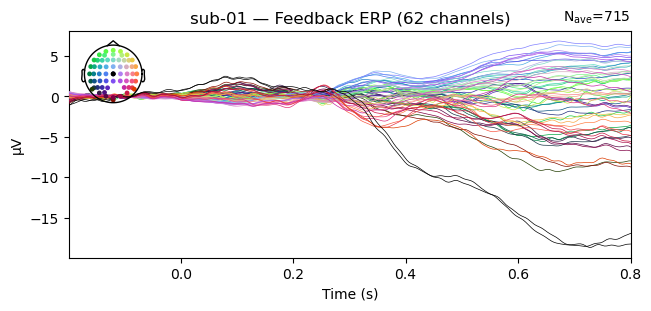

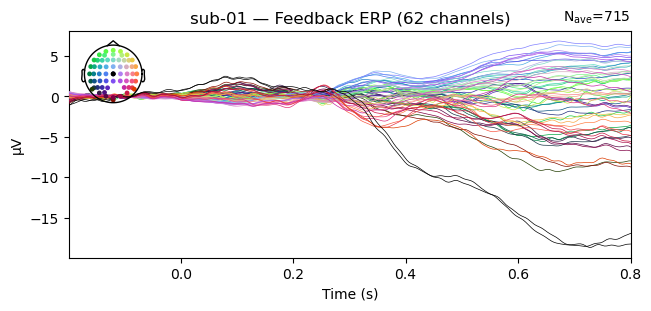

In [61]:
%matplotlib inline
# PSD of cleaned continuous data
raw_erp.compute_psd(fmax=50).plot(average=True)

# Prefer cleaned epochs for final QC plots when available
epochs_for_qc = epochs_fb_clean if "epochs_fb_clean" in globals() else epochs_fb

# Epoch image (mean across channels)
epochs_for_qc.plot_image(
    combine="mean",
    title=f"sub-{SUBJECT} — Epoch image (mean across channels)"
)

# Grand-average ERP butterfly
evoked = epochs_for_qc.average()
evoked.plot(titles=f"sub-{SUBJECT} — Feedback ERP")

In [62]:
# --- Optional: reload and verify saved files ---
if "prefix" not in globals():
    prefix = f"sub-{SUBJECT}_ses-{SESSION}_task-{TASK}"
if "epochs_path" not in globals():
    epochs_path = out_dir / f"{prefix}_epochs_feedback_clean-epo.fif"

expected_epochs = epochs_fb_clean if "epochs_fb_clean" in globals() else epochs_fb
expected_n = len(expected_epochs)

_epochs_check = mne.read_epochs(str(epochs_path), verbose=False)
assert len(_epochs_check) == expected_n, (
    f"Epoch count mismatch after reload: {len(_epochs_check)} != {expected_n}"
)
assert _epochs_check.info["sfreq"] == raw_erp.info["sfreq"]

if "metadata" in globals() and metadata is not None:
    assert _epochs_check.metadata is not None, "Metadata missing after reload"
    assert len(_epochs_check.metadata) == expected_n
    print("Verification passed: saved files are consistent (including metadata)")
else:
    print("Verification passed: saved files are consistent (metadata check skipped)")

del _epochs_check

Verification passed: saved files are consistent (metadata check skipped)


Dropped from plotting only: ['EXG1', 'EXG2']


/var/folders/bg/35xhpjxn5mn8n4n2k4h8pc8w0000gn/T/ipykernel_45511/811960245.py:23: RuntimeWarning: Only 1 channel in "picks"; cannot combine by method "mean".
  mne.viz.plot_compare_evokeds(


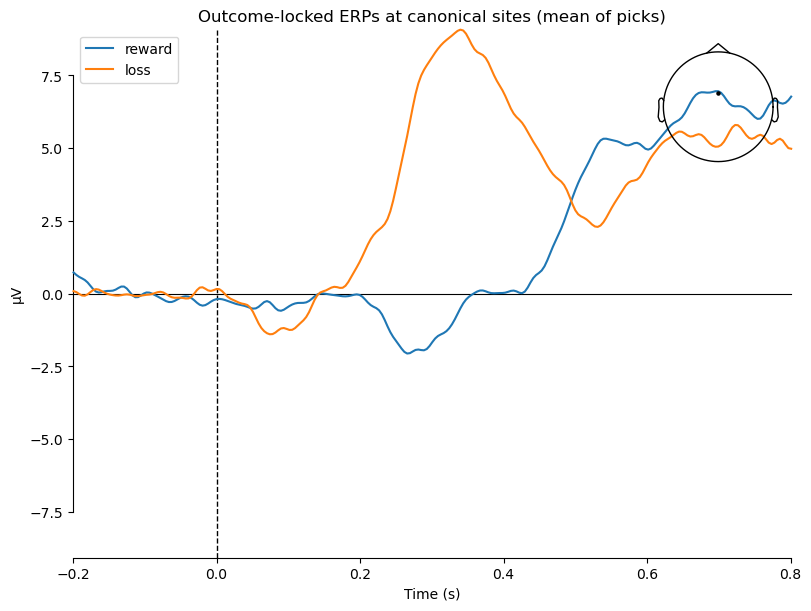

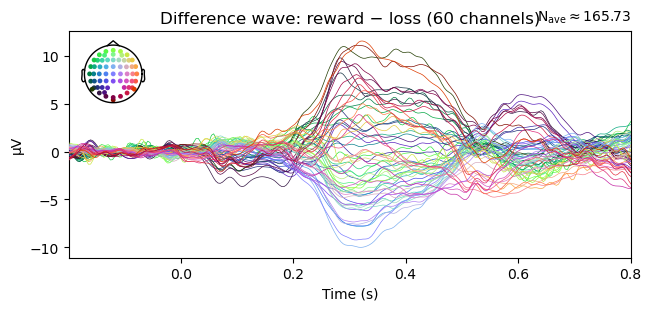

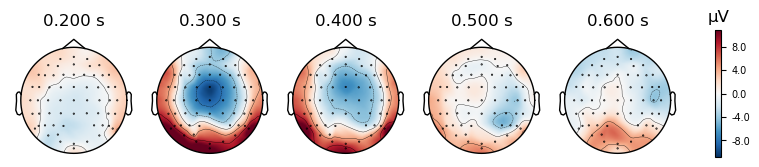

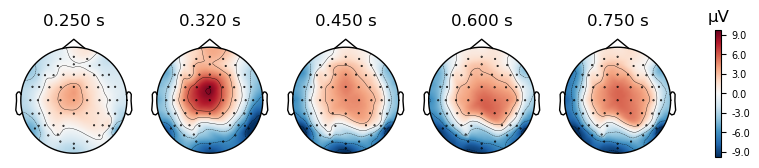

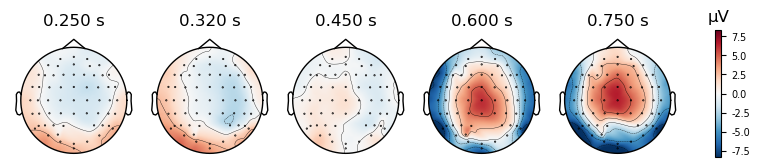

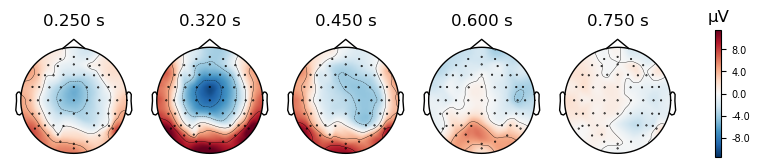

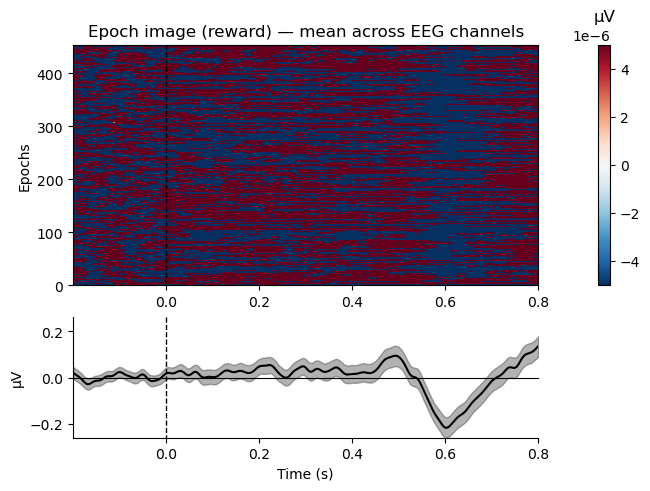

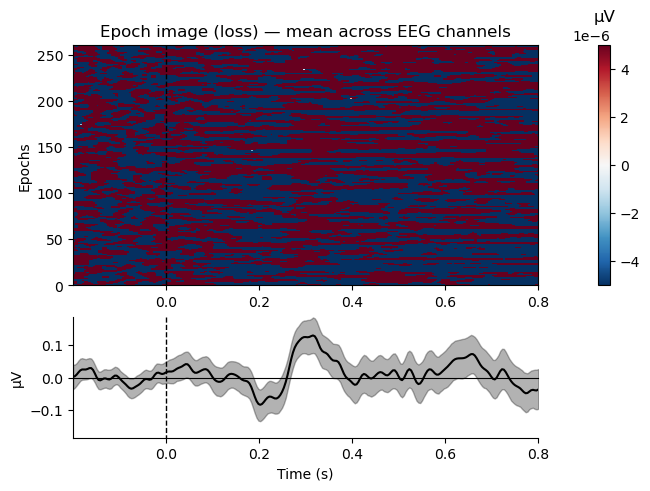

Kept epochs: {'reward': 454, 'loss': 261}
Pre-drop epochs: {'reward': 457, 'loss': 262}
Drop rates: {'reward': 0.006564551422319487, 'loss': 0.003816793893129722}


In [63]:

import matplotlib.pyplot as plt

# Convenience
epochs = epochs_fb_clean
assert len(epochs) > 0

# Plotting-only copy: remove overlapping mastoid EXG channels from topomap visualizations
plot_drop_channels = [ch for ch in ["EXG1", "EXG2"] if ch in epochs.ch_names]
epochs_plot = epochs.copy()
if plot_drop_channels:
    epochs_plot.drop_channels(plot_drop_channels)
    print(f"Dropped from plotting only: {plot_drop_channels}")

# Optional: standard ERP settings
mne.set_log_level("WARNING")

picks = ['FCz'] #["Fz", "FCz", "Cz", "Pz"]
picks = [p for p in picks if p in epochs_plot.ch_names]

ev_reward = epochs_plot["reward"].average()
ev_loss = epochs_plot["loss"].average()

mne.viz.plot_compare_evokeds(
    {"reward": ev_reward, "loss": ev_loss},
    picks=picks,
    combine="mean",  # mean across selected channels
    title="Outcome-locked ERPs at canonical sites (mean of picks)",
    show=True,
)

ev_diff = mne.combine_evoked([ev_reward, ev_loss], weights=[1, -1])
ev_diff.comment = "reward-minus-loss"

# Butterfly of the difference wave
ev_diff.plot(spatial_colors=True, titles="Difference wave: reward − loss", show=True)

# A compact sensor-time plot: find peak in a broad window
time_window = (0.2, 0.6)
ev_diff.plot_topomap(
    times=np.linspace(time_window[0], time_window[1], 5),
    ch_type="eeg",
    time_unit="s",
    show=True,
 )

times = [0.25, 0.32, 0.45, 0.60, 0.75]  # seconds
for evk, name in [(ev_loss, "loss"), (ev_reward, "reward"), (ev_diff, "reward−loss")]:
    fig = evk.plot_topomap(
        times=times,
        ch_type="eeg",
        time_unit="s",
        show=True,
    )
    if hasattr(fig, "suptitle"):
        fig.suptitle(f"Topomaps: {name}")

for cond in ["reward", "loss"]:
    ep = epochs_plot[cond]
    ep.plot_image(
        picks="eeg",
        combine="mean",
        sigma=1.0,
        vmin=-5e-6,
        vmax=5e-6,  # adjust if needed
        title=f"Epoch image ({cond}) — mean across EEG channels",
        show=True,
    )


# counts after cleaning
n_reward = len(epochs_plot["reward"])
n_loss   = len(epochs_plot["loss"])
print("Kept epochs:", {"reward": n_reward, "loss": n_loss})

# If you have the pre-drop epochs stored, you can compute drop rates:
if "epochs_fb" in globals():
    pre = epochs_fb
    print("Pre-drop epochs:", {"reward": len(pre["reward"]), "loss": len(pre["loss"])})
    drop_reward = 1 - (len(epochs_plot["reward"]) / max(1, len(pre["reward"])))
    drop_loss   = 1 - (len(epochs_plot["loss"]) / max(1, len(pre["loss"])))
    print("Drop rates:", {"reward": drop_reward, "loss": drop_loss})

---

**Pipeline complete.** All outputs have been saved to:

```
data/derivatives/mne_preproc/sub-XX/ses-XX/
    *_raw_clean.fif
    *_ica.fif
    *_epochs_feedback_clean-epo.fif
    *_qc_summary.json
```

Next steps (outside this notebook):
- ERP analysis: load `*_epochs_feedback_clean-epo.fif`, compute condition
  averages, cluster-based permutation tests
- Computational modelling: use `epochs.metadata` columns and
  `qc_summary.json` to align model regressors with cleaned trials